In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import spacy

!pip install spacy

!python -m spacy download en_core_web_lg

In [2]:
nlp = spacy.load('en_core_web_lg')

In [3]:
def sent_tokenization(text):
    doc = nlp(text)
    sent = [i.text for i in doc.sents]
    return sent
def word_tokenization(text):
    doc = nlp(text)
    words = [word for word in doc]
    return words
def lemmatization(text):
    return [word.lemma_ for word in text]

from nltk import corpus
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
stop_words.remove('not')
stop_words.remove('but')
stop_words.remove('very') #if,few,no

def stopword_removal(text):
    return [word for word in text if str(word) not in stop_words]

In [4]:
import re

def cleaning(df):
    df['tokenized'] = df['Review'].apply(sent_tokenization)
    nested_list = [(df['review_id'][i],df['Name'][i],df['Date'][i],df['Type_of_review'][i],
                   df['Rating'][i],df['Type Of Traveller'][i],df['Seat Type'][i],df['Recommended'][i],j)\
                  for i in range(df['tokenized'].shape[0])\
                  for j in df['tokenized'][i]   ]
    data = pd.DataFrame(nested_list,columns=['Review_id','Name','Date','Type_of_review','Rating','Type_of_traveller','Seat_type','Recommended','Sentence'])
    print(data.head())
    
    #lowercasing the sentence
    data['Sentence'] = data['Sentence'].apply(lambda sent:sent.lower())
    #removing the punctuations and numbers
    data['cleaned_sentence'] = data['Sentence'].apply(lambda sent:re.sub(r'[^A-Za-z\s]','',sent))
    #removing the extra whitespaces in between the text
    data['cleaned_sentence'] = data['cleaned_sentence'].apply(lambda sent:re.sub(r'\s+',' ',sent))
    #removing the extra whitespaces in front and end of text
    data['cleaned_sentence'] = data['cleaned_sentence'].apply(lambda sent:sent.strip())
    #converting the sentence into words
    data['words'] = data['cleaned_sentence'].apply(word_tokenization)
    #lemmitization
    data['words'] = data['words'].apply(lemmatization)
    #stopwords removal
    data['words'] = data['words'].apply(stopword_removal)
    data['merged_words'] = data['words'].apply(lambda word:' '.join(word))
    df_flagmatrix = map_topics(data['words'])
    flagmatrix,aggregate,data = sentiment_analysis(data,df_flagmatrix) 
    
    return df_flagmatrix,flagmatrix,data,aggregate
    

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
def map_topics(word_column):
    
    df_flagmatrix = pd.DataFrame(0,index = range(len(word_column)),columns=map_words.keys())
    
    for index,words in enumerate(word_column):
        for topic,wordlist in map_words.items():
            if any(word in wordlist for word in words):
                df_flagmatrix.loc[index,topic]=1
                break
    return df_flagmatrix
    
def sentiment_analysis(df,df_flagmatrix):
    df['pos_scores'] = df['merged_words'].apply(lambda x:sia.polarity_scores(x)['pos'])
    df['neu_scores'] = df['merged_words'].apply(lambda x:sia.polarity_scores(x)['neu'])
    df['neg_scores'] = df['merged_words'].apply(lambda x:sia.polarity_scores(x)['neg'])
    df['compound_scores'] = df['merged_words'].apply(lambda x:sia.polarity_scores(x)['compound']*5)
    cs = pd.DataFrame(columns=['compound'])
    cs['compound']= df['merged_words'].apply(lambda x:sia.polarity_scores(x)['compound']*5)
    
    flagmatrix = df_flagmatrix.copy().astype(float)
    
    for i in range(flagmatrix.shape[0]):
        for j in range(flagmatrix.shape[1]):
            if flagmatrix.iloc[i,j] ==1:
                flagmatrix.iloc[i,j] = flagmatrix.iloc[i,j]*cs.iloc[i,0]
                
    avg = []
    for col in range(flagmatrix.shape[1]):
        sum1 = n = 0
        for row in range(flagmatrix.shape[0]):
            if flagmatrix.iloc[row,col]!=0:
                n+=1
                sum1+=flagmatrix.iloc[row,col]
        if n!=0:
            avg.append(sum1/n)
        else:
            avg.append(0)
    
    topics = map_words.keys()
    avg = np.array(avg)
    aggregate = pd.DataFrame(avg.reshape(1,10),columns=topics)
    return flagmatrix,aggregate,df


In [6]:
map_words = {
    'Flight Booking': ['board', 'boarding', 'book', 'booking', 'cancel', 'cancellation', 'ticket',
        'confirm', 'confirmation', 'itinerary', 'reserve', 'reservation', 'change', 'modify',
        'details', 'update', 'status', 'availability','process', 'upgrade', 'downgrade','rebooking',
        'travel', 'plan', 'class','portal', 'online', 'app','details','email',
        'policy','voucher', 'date','modify'],
    'Staff Service': ['crew', 'attendant', 'friendly', 'staff', 'hostess', 'polite', 'answer',
        'behave', 'behavior', 'courteous', 'member', 'rude', 'attitude', 'cooperative',
        'unprofessional', 'helpful', 'kind', 'patient', 'assist', 'handle', 'responsive',
        'interaction', 'team', 'supportive', 'cheerful','trained', 'help',
        'assistance', 'professional', 'smile', 'efficient','personnel', 'respectful',
        'communication', 'handling', 'manager', 'greet', 'welcome', 'care',
        'empathy', 'issues', 'attentive', 'inform','instructions'],
    'Fare': ['economy', 'price', 'budget', 'charge', 'cheap', 'cost', 'fee', 'lowcost', 'money',
        'fare', 'amount', 'payment', 'value', 'expensive', 'discount', 'offer', 'deal', 'rate',
        'affordable', 'reasonable', 'competitive', 'costly', 'high', 'cost-effective', 'saving',
        'price-sensitive','economical','premium', 'low-fare', 'bargain','quote', 'hidden', 'extra',
        'affordable','high-cost', 'pricing-policy','inclusive', 'transparent'],
    'Food': ['breakfast', 'drink', 'food', 'meal', 'snack', 'veg', 'water', 'dinner', 'hospitality',
        'serve', 'beverage', 'refreshment', 'sandwich', 'cuisine', 'taste', 'menu','quantity','lunch'
        'variety', 'non-veg', 'spicy', 'dessert', 'appetizer', 'portion','flavor', 'delicious',
        'bland', 'healthy', 'juice','order','tea', 'coffee', 'milk','beef', 'vegetarian', 'vegan',
        'rice','bread','butter','peanut', 'limited', 'choices', 'meal-pack', 'packaging', 'offer'],
    'Flight Features': ['domestic', 'international','toilet', 'lounge', 'washroom', 'facility',
        'wifi', 'entertainment', 'screen','power', 'headphones', 'legroom', 
        'feature', 'amenity', 'cabin','interior', 'ambient', 'air-conditioning', 
        'recliner', 'aisle', 'lighting', 'TV','charger','design', 'privacy', 'music',
        'restroom','arrangement','windows','views','seatbelt','temperature','tablet',
        'display', 'upgrade','convenience', 'features'],
    'Cleanliness': ['dirty', 'clean', 'maintenance','hygiene', 'sanitary', 'neat', 'tidy', 'filthy',
        'spotless', 'fresh', 'organized', 'smell', 'stain', 'cleaner', 'disinfect',
        'hygienic', 'dust', 'odor', 'trash', 'messy', 'sanitize', 'germs','sterile', 'freshener',
        'mop', 'garbage', 'clutter', 'scrub', 'neatness', 'litter','shiny', 'health', 'proper',
        'disorder', 'bathroom', 'filth', 'dirty-smell','unhygienic', 'dust-free'],
    'Special Assistance': ['assistance', 'support', 'accessibility', 'priority',
        'wheelchair', 'oxygen', 'guide', 'aid', 'medical', 'escort', 'special',
        'mobility', 'elderly', 'disable', 'needs','arrangement','handicap','assist',
        'disability','infirm','accessible', 'provision', 'mobility', 'special-care','elder',
        'stress-free','concierge', 'navigation','inclusive'],
    'Customer Service': ['customer', 'service', 'call', 'support', 'response', 'issue', 'resolve', 'complaint',
        'feedback','query', 'helpdesk', 'contact','prompt', 'rating', 'review', 'call-center', 
        'unresolve', 'solve', 'dissatisfy', 'answer','assistance',
        'queries','solution'],
    'Time Management': ['arrival', 'arrive', 'delay', 'depart', 'departure', 'early', 'late',
        'later', 'schedule', 'time', 'wait', 'timing', 'punctual','timely', 'duration', 'on-time','timeliness',
        'postpone','overtime', 'late-arrival','sharp','delayed', 'estimated',
        'lateness', 'wait-time', 'quick', 'timed', 'early-departure', 'delays'],
    'Seat Comfort': ['comfortable', 'seat', 'uncomfortable', 'comfort', 'seating', 'cushion', 'adjust',
        'cramp', 'recline', 'padding', 'armrest','tight', 'backrest', 'footrest', 'design', 'soft',
        'angle', 'headrest', 'lean','front', 'rear', 'softness', 'comfort-level',
        'personal-space','cozy','fabric', 'smooth']
}


In [7]:
df1 = pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='alliance_air')
df1.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,Yash Biyani,23rd July 2024,['Not Verified'],1,['The airline unexpectedly cancelled the fligh...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN
1,2,Pradeep Manyam,29th April 2024,['Not Verified'],1,[' This flight has some bad history of cancel...,NaN,Family Leisure,Economy Class,Amritsar to Shimla,July 2024,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no
2,3,S Karheen,24th March 2024,['Trip Verified'],1,"["" I had the misfortune of booking my mother'...",ATR700,Family Leisure,Economy Class,Bengaluru to Vijayawada,April 2024,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no
3,4,T Markabu,18th March 2024,['Trip Verified'],1,[' It was the worst flight ever I used in my ...,NaN,Couple Leisure,Economy Class,Salem to Bangalore,March 2024,NaN,NaN,NaN,NaN,2.0,NaN,1.0,no
4,5,Ananya Arandula,13th March 2024,['Not Verified'],1,"[""Worst airline ever. Our round trip flights g...",NaN,Solo Leisure,Economy Class,Bangalore to Vijayawada,March 2024,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no


In [8]:
df_flagmatrix1,flagmatrix1,df1,alliance_air = cleaning(df1)
alliance_air

   Review_id         Name            Date    Type_of_review  Rating  \
0          1  Yash Biyani  23rd July 2024  ['Not Verified']       1   
1          1  Yash Biyani  23rd July 2024  ['Not Verified']       1   
2          1  Yash Biyani  23rd July 2024  ['Not Verified']       1   
3          1  Yash Biyani  23rd July 2024  ['Not Verified']       1   
4          1  Yash Biyani  23rd July 2024  ['Not Verified']       1   

  Type_of_traveller Seat_type Recommended  \
0               NaN       NaN         NaN   
1               NaN       NaN         NaN   
2               NaN       NaN         NaN   
3               NaN       NaN         NaN   
4               NaN       NaN         NaN   

                                            Sentence  
0  ['The airline unexpectedly cancelled the fligh...  
1  This not only caused inconvenience but further...  
2  However, the money that was already paid for h...  
3       Will never recommend this airline to anyone.  
4  If they cannot ensure re

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,-0.981671,-0.537679,-0.505955,0.638333,0.535556,-0.809,-1.5445,-1.584575,-1.424675,1.839833


In [9]:
df2 = pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='air_india')
df2.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,Johanna Gomez,30th July 2024,['Not Verified'],1.0,[' Will never fly with Air India again. Itine...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,3.0,2.0,NaN,NaN,NaN,NaN
1,2,C Ranaja,29th July 2024,['Trip Verified'],2.0,"["" If Air India has such lousy in-flight ente...",AI 308,Solo Leisure,Economy Class,Delhi to Melbourne/Gold Coast,July 2024,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no
2,3,Noel Francis Lukwaro,27th July 2024,['Not Verified'],1.0,"[' The plane was so old and broken, everythin...",Boeing 787-9,Family Leisure,Economy Class,Washington to Delhi,July 2024,3.0,3.0,2.0,1.0,4.0,1.0,2.0,no
3,4,Ashna John,21st July 2024,['Not Verified'],1.0,"[""I requested to cancel my ticket and had to d...",NaN,Couple Leisure,Economy Class,Colombo to Copenhagen via New Delhi,July 2024,1.0,1.0,1.0,NaN,1.0,NaN,1.0,no
4,5,J Horsman,19th July 2024,['Not Verified'],1.0,[' The worst flight I have ever been on. I ha...,NaN,Solo Leisure,Economy Class,London to Seoul via Delhi,May 2024,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [10]:
df_flagmatrix2,flagmatrix2,df2,air_india = cleaning(df2)
air_india

   Review_id           Name            Date    Type_of_review  Rating  \
0          1  Johanna Gomez  30th July 2024  ['Not Verified']     1.0   
1          1  Johanna Gomez  30th July 2024  ['Not Verified']     1.0   
2          1  Johanna Gomez  30th July 2024  ['Not Verified']     1.0   
3          1  Johanna Gomez  30th July 2024  ['Not Verified']     1.0   
4          1  Johanna Gomez  30th July 2024  ['Not Verified']     1.0   

  Type_of_traveller Seat_type Recommended  \
0               NaN       NaN         NaN   
1               NaN       NaN         NaN   
2               NaN       NaN         NaN   
3               NaN       NaN         NaN   
4               NaN       NaN         NaN   

                                            Sentence  
0           ['  Will never fly with Air India again.  
1  Itinerary was New Delhi to Gold Coast, stoppin...  
2  I confirmed multiple times that I did not have...  
3  I would only need to collect my luggage on the...  
4  What went wr

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,-0.025817,0.424961,0.716912,0.603512,0.866753,-0.254863,0.367185,-0.451648,-0.568529,0.664519


In [11]:
df_flagmatrix2.sum(axis=0)

Flight Booking        2156
Staff Service         1871
Fare                   554
Food                  1048
Flight Features        884
Cleanliness            156
Special Assistance      40
Customer Service       538
Time Management        941
Seat Comfort           367
dtype: int64

In [12]:
df3 = pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='air_asia_india')
df3.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,V Bakshi,14th October 2023,['Trip Verified'],6,[' I had booked this fare at a very discounted...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,3.0,2.0,NaN,NaN,NaN,NaN
1,2,G Oscar,22nd September 2023,['Trip Verified'],1,[' I travel at least four times a month and Ai...,A320Ceo,Solo Leisure,Economy Class,Mumbai to Bengaluru,October 2023,3.0,4.0,NaN,NaN,4.0,NaN,5.0,yes
2,3,Rahul Verma,16th September 2023,['Trip Verified'],10,[' Taking this opportunity to appreciate and t...,NaN,Business,Economy Class,Mumbai to Bangalore,September 2023,2.0,2.0,1.0,1.0,1.0,1.0,1.0,no
3,4,G Akron,8th September 2023,['Trip Verified'],1,"["" The worst airlines in the history of mankin...",A320,Family Leisure,Economy Class,Kochi to Delhi,September 2023,5.0,5.0,1.0,1.0,4.0,1.0,4.0,yes
4,5,Sirajudeen Jawahar ali,3rd July 2023,['Trip Verified'],8,[' Would like to give big thumbs up to boardi...,NaN,Solo Leisure,Economy Class,Mumbai to Lucknow,September 2023,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [13]:
df_flagmatrix3,flagmatrix3,df3,air_asia = cleaning(df3)
air_asia

   Review_id      Name               Date     Type_of_review  Rating  \
0          1  V Bakshi  14th October 2023  ['Trip Verified']       6   
1          1  V Bakshi  14th October 2023  ['Trip Verified']       6   
2          1  V Bakshi  14th October 2023  ['Trip Verified']       6   
3          1  V Bakshi  14th October 2023  ['Trip Verified']       6   
4          1  V Bakshi  14th October 2023  ['Trip Verified']       6   

  Type_of_traveller Seat_type Recommended  \
0               NaN       NaN         NaN   
1               NaN       NaN         NaN   
2               NaN       NaN         NaN   
3               NaN       NaN         NaN   
4               NaN       NaN         NaN   

                                            Sentence  
0  [' I had booked this fare at a very discounted...  
1  The check in experience was good, I had arrive...  
2  Post that I had noticed that the inbound was d...  
3  The crew were welcoming and this flight was no...  
4  During boarding I 

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,0.282127,1.246862,0.209821,0.953409,0.15265,3.592,1.239417,-0.533983,-0.417684,1.097632


In [14]:
df_flagmatrix3.sum(axis=0)

Flight Booking        187
Staff Service         122
Fare                   54
Food                   18
Flight Features        16
Cleanliness             1
Special Assistance      6
Customer Service       44
Time Management        58
Seat Comfort           29
dtype: int64

In [15]:
df4 = pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='airindia_express')
df4.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,Ravi Ranjan Singh,1st March 2025,['Trip Verified'],1.0,[' These are the worst service provider. My ...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
1,2,Mohamed Anis,13th February 2025,['Trip Verified'],1.0,"["" I am writing to express my disappointment...",NaN,Solo Leisure,Economy Class,Bangalore to Kolkata,February 2025,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no
2,3,Sunprova Borah,12th February 2025,['Trip Verified'],1.0,['\xa0 \xa0Airport team charged extra for the ...,NaN,Solo Leisure,Economy Class,Kolkatta to Cochin via Bhubaneshwar,February 2025,4.0,4.0,NaN,NaN,1.0,NaN,1.0,no
3,4,Nilesh Jeurkar,11th February 2025,['Trip Verified'],1.0,[' My flight was scheduled for 15:45 from Mumb...,NaN,Family Leisure,Economy Class,Dibrugarh to Bengaluru,February 2025,3.0,3.0,3.0,1.0,2.0,1.0,1.0,no
4,5,H Darshun,10th February 2025,['Trip Verified'],2.0,[' Garbage flight service of Air India expre...,NaN,Business,Economy Class,Mumbai to Jaipur,February 2025,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no


In [16]:
df_flagmatrix4,flagmatrix4,df4,air_india_express= cleaning(df4)
air_india_express

   Review_id               Name            Date     Type_of_review  Rating  \
0          1  Ravi Ranjan Singh  1st March 2025  ['Trip Verified']     1.0   
1          1  Ravi Ranjan Singh  1st March 2025  ['Trip Verified']     1.0   
2          1  Ravi Ranjan Singh  1st March 2025  ['Trip Verified']     1.0   
3          1  Ravi Ranjan Singh  1st March 2025  ['Trip Verified']     1.0   
4          1  Ravi Ranjan Singh  1st March 2025  ['Trip Verified']     1.0   

  Type_of_traveller Seat_type Recommended  \
0               NaN       NaN         NaN   
1               NaN       NaN         NaN   
2               NaN       NaN         NaN   
3               NaN       NaN         NaN   
4               NaN       NaN         NaN   

                                            Sentence  
0         ['   These are the worst service provider.  
1  My flight was delayed to 6:40 PM initially fro...  
2        Now again my flight was delayed to 7:20 pm.  
3  I had a connecting Train to my hometo

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,-0.355955,0.213612,0.308412,0.67485,0.217855,-1.7695,-0.3115,-0.512844,-1.29685,-0.026518


In [17]:
df5 = pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='akasa')
df5.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,P Bajwa,2nd August 2024,['Trip Verified'],2,[' It was a horrible experience as a first tim...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,2,Ashwini Lokanath,2nd August 2024,['Not Verified'],1,['I’m utterly disgusted with the service provi...,QP1385,Solo Leisure,Economy Class,Bhubaneswar to Bangalore,August 2024,1.0,1.0,NaN,NaN,1.0,NaN,2.0,no
2,3,Shubhada Thakur,28th July 2024,['Trip Verified'],10,[' My grandfather traveled from Delhi to Mumb...,NaN,Couple Leisure,Economy Class,Bangalore to Pune,August 2024,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no
3,4,Yaswanthkumar Yaram,24th July 2024,['Not Verified'],1,[' Worst experience and flight delayed by 8hr...,NaN,Solo Leisure,Economy Class,Delhi to Mumbai,July 2024,5.0,5.0,NaN,NaN,5.0,NaN,5.0,yes
4,5,Anushka Bhoir,15th July 2024,['Not Verified'],1,[' My recent experiences with Akasa Air have ...,NaN,Family Leisure,Economy Class,Goa to Bangalore,July 2024,1.0,1.0,1.0,1.0,1.0,1.0,2.0,no


In [18]:
df_flagmatrix5,flagmatrix5,df5,akasa= cleaning(df5)
akasa

   Review_id     Name             Date     Type_of_review  Rating  \
0          1  P Bajwa  2nd August 2024  ['Trip Verified']       2   
1          1  P Bajwa  2nd August 2024  ['Trip Verified']       2   
2          1  P Bajwa  2nd August 2024  ['Trip Verified']       2   
3          1  P Bajwa  2nd August 2024  ['Trip Verified']       2   
4          1  P Bajwa  2nd August 2024  ['Trip Verified']       2   

  Type_of_traveller Seat_type Recommended  \
0               NaN       NaN         NaN   
1               NaN       NaN         NaN   
2               NaN       NaN         NaN   
3               NaN       NaN         NaN   
4               NaN       NaN         NaN   

                                            Sentence  
0  [' It was a horrible experience as a first tim...  
1  I am frequent flyer and opted AKASA AIR SERVIC...  
2  I reached for check in at 15.10 and the Flight...  
3  They still had 45 minutes in their hands but n...  
4  Such a ruckus for all, 10 passengers

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,-0.12536,0.849771,0.192226,-0.082654,1.8851,1.25455,1.399591,-0.141425,-0.456167,0.395045


In [19]:
df6 = pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='goair')
df6.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,Gladson Daniel,26th November 2021,['Trip Verified'],1.0,[' They Simply cancelled the flight. Which af...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
1,2,Aaron Dsouza,14th November 2021,['Not Verified'],1.0,"[' Pathetic front desk, impolite and worst sta...",NaN,Solo Leisure,Economy Class,Chennai to Colombo,November 2021,NaN,NaN,NaN,NaN,NaN,NaN,1.0,no
2,3,Deepak Saha,16th August 2021,['Trip Verified'],1.0,[' Worst Airline ever I have come across so f...,NaN,Business,Economy Class,Mangalore to Mumbai,November 2021,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no
3,4,Pratheesh KR,5th August 2021,['Trip Verified'],1.0,"["" I arrived early for my scheduled flight Ko...",NaN,Solo Leisure,Economy Class,NaN,August 2021,NaN,NaN,NaN,NaN,1.0,NaN,1.0,no
4,5,R Heller,3rd August 2021,['Trip Verified'],1.0,[' I booked a flight on August 2nd for 4 memb...,NaN,Family Leisure,Economy Class,Kochi to Mumbai via Srinagar,August 2021,1.0,1.0,1.0,1.0,1.0,NaN,1.0,no


In [20]:
df_flagmatrix6,flagmatrix6,df6,goair = cleaning(df6)
goair

   Review_id            Name                Date     Type_of_review  Rating  \
0          1  Gladson Daniel  26th November 2021  ['Trip Verified']     1.0   
1          1  Gladson Daniel  26th November 2021  ['Trip Verified']     1.0   
2          1  Gladson Daniel  26th November 2021  ['Trip Verified']     1.0   
3          1  Gladson Daniel  26th November 2021  ['Trip Verified']     1.0   
4          2    Aaron Dsouza  14th November 2021   ['Not Verified']     1.0   

  Type_of_traveller      Seat_type Recommended  \
0               NaN            NaN         NaN   
1               NaN            NaN         NaN   
2               NaN            NaN         NaN   
3               NaN            NaN         NaN   
4      Solo Leisure  Economy Class          no   

                                            Sentence  
0              ['  They Simply cancelled the flight.  
1                Which affects all my vacation plan.  
2          No proper response from the airline team.  
3  W

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,-0.61517,0.045716,-0.2485,0.806233,0.17175,1.516313,0.404438,-0.970839,-0.771581,-1.003781


In [21]:
df_flagmatrix6.sum(axis=0)

Flight Booking        485
Staff Service         181
Fare                   84
Food                   32
Flight Features        25
Cleanliness            10
Special Assistance     11
Customer Service      138
Time Management       149
Seat Comfort           29
dtype: int64

In [22]:
df7 = pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='gofirst')
df7.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,G Mandal,2nd May 2023,['Trip Verified'],1,[' Cancelled the flight at last moment and rui...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN
1,2,Vishwanath Deshpande,2nd May 2023,['Not Verified'],1,[' The worst ever flight. They cancel your fli...,NaN,Couple Leisure,Economy Class,Ahmedabad to Delhi,December 2022,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no
2,3,Akash Raval,2nd May 2023,['Trip Verified'],1,[' Worst airline. This is the 2nd time we hav...,NaN,Family Leisure,Economy Class,Ahmedabad to Bengaluru,May 2023,NaN,NaN,NaN,NaN,1.0,NaN,1.0,no
3,4,K Gupta,2nd May 2023,['Trip Verified'],1,[' My flight got cancelled without any notific...,NaN,Business,Economy Class,Ahmedabad to Bangalore,February 2023,NaN,NaN,NaN,NaN,1.0,NaN,1.0,no
4,5,M Reddy,27th April 2023,['Trip Verified'],1,"["" Delaying flights by 5-6 hrs and changing th...",NaN,Family Leisure,Economy Class,Bangalore to Ranchi,May 2023,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [23]:
df_flagmatrix7,flagmatrix7,df7,go_first = cleaning(df7)
go_first

   Review_id                  Name          Date     Type_of_review  Rating  \
0          1              G Mandal  2nd May 2023  ['Trip Verified']       1   
1          1              G Mandal  2nd May 2023  ['Trip Verified']       1   
2          2  Vishwanath Deshpande  2nd May 2023   ['Not Verified']       1   
3          2  Vishwanath Deshpande  2nd May 2023   ['Not Verified']       1   
4          2  Vishwanath Deshpande  2nd May 2023   ['Not Verified']       1   

  Type_of_traveller      Seat_type Recommended  \
0               NaN            NaN         NaN   
1               NaN            NaN         NaN   
2    Couple Leisure  Economy Class          no   
3    Couple Leisure  Economy Class          no   
4    Couple Leisure  Economy Class          no   

                                            Sentence  
0  [' Cancelled the flight at last moment and rui...  
1  Beware of this type of airlines as now I try t...  
2                          [' The worst ever flight.  
3   

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,-0.811573,-0.405327,-0.601942,0.181125,0.82185,-0.4319,-0.326333,-1.428908,-1.041522,-0.348733


In [24]:
df_flagmatrix7.sum(axis=0)

Flight Booking        455
Staff Service         138
Fare                   70
Food                    7
Flight Features        14
Cleanliness             6
Special Assistance      6
Customer Service      105
Time Management       144
Seat Comfort           17
dtype: int64

In [25]:
df8=pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='indigo')
df8.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,Saramma Pa,2nd August 2024,['Not Verified'],1.0,['Worst Airline. Delayed first leg and missed ...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,3.0,1.0,NaN,NaN,NaN,NaN
1,2,Manoj Jena,26th July 2024,['Trip Verified'],1.0,"["" This flight I missed due to airline ignora...",NaN,Family Leisure,Economy Class,Bengaluru to Bahrain via Mumbai,August 2024,2.0,1.0,NaN,NaN,1.0,NaN,1.0,no
2,3,Gaspard Grass,23rd June 2024,['Not Verified'],5.0,[' \xa0My Indigo flight 6E-11 DEL-IST on 17 ju...,NaN,Solo Leisure,Economy Class,Pune to Delhi,July 2024,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no
3,4,Namrata Dubey,10th June 2024,['Trip Verified'],1.0,"["" My sister had flight today at 1:25 from Lu...",Boeing 777,Solo Leisure,Economy Class,Delhi to Istanbul,June 2024,3.0,4.0,2.0,1.0,3.0,NaN,3.0,no
4,5,L Gomil,9th June 2024,['Trip Verified'],1.0,"["" Worst experience. They are the worst staff...",NaN,Family Leisure,Economy Class,Lucknow to Ahmedabad,June 2024,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no


In [26]:
df_flagmatrix8,flagmatrix8,df8,indigo = cleaning(df8)
indigo

   Review_id        Name             Date     Type_of_review  Rating  \
0          1  Saramma Pa  2nd August 2024   ['Not Verified']     1.0   
1          1  Saramma Pa  2nd August 2024   ['Not Verified']     1.0   
2          1  Saramma Pa  2nd August 2024   ['Not Verified']     1.0   
3          2  Manoj Jena   26th July 2024  ['Trip Verified']     1.0   
4          2  Manoj Jena   26th July 2024  ['Trip Verified']     1.0   

  Type_of_traveller      Seat_type Recommended  \
0               NaN            NaN         NaN   
1               NaN            NaN         NaN   
2               NaN            NaN         NaN   
3    Family Leisure  Economy Class          no   
4    Family Leisure  Economy Class          no   

                                            Sentence  
0                                   ['Worst Airline.  
1    Delayed first leg and missed connecting flight.  
2  Ground staff and counter staff worst attitude ...  
3  ["  This flight I missed due to airline ign

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,0.370822,1.494451,0.697362,0.868867,1.222455,1.887148,0.855727,0.201706,-0.368744,0.698102


In [27]:
df_flagmatrix8.sum(axis=0)

Flight Booking        740
Staff Service         624
Fare                  258
Food                  172
Flight Features       125
Cleanliness            46
Special Assistance     24
Customer Service      135
Time Management       308
Seat Comfort          104
dtype: int64

In [28]:
df9=pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='spicejet')
df9.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,K Mansour,21st July 2024,['Trip Verified'],10.0,[' I have had good service by the crew. It was...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,2,A Kajan,18th July 2024,['Trip Verified'],10.0,"["" It's very grateful to SpiceJet for the ser...",NaN,Solo Leisure,Economy Class,Calicut to Dubai,July 2024,5.0,5.0,5.0,5.0,5.0,1.0,5.0,yes
2,3,Satvir Singh,9th July 2024,['Trip Verified'],1.0,"[""\xa0 \xa0I have been waiting from 3 hours an...",NaN,Family Leisure,Economy Class,Kolkata to Delhi,July 2024,5.0,5.0,5.0,NaN,5.0,NaN,5.0,yes
3,4,Z Hakira,6th July 2024,['Trip Verified'],3.0,[' I would not recommend SpiceJet as they fre...,NaN,Solo Leisure,Economy Class,Dubai to Mumbai,July 2024,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no
4,5,A Masyan,6th July 2024,['Trip Verified'],1.0,[' It’s been 4th time already since my flight...,NaN,Family Leisure,Economy Class,Srinagar to Mumbai,July 2024,2.0,2.0,2.0,NaN,1.0,1.0,1.0,no


In [29]:
df_flagmatrix9,flagmatrix9,df9,spice_jet = cleaning(df9)
spice_jet

   Review_id       Name            Date     Type_of_review  Rating  \
0          1  K Mansour  21st July 2024  ['Trip Verified']    10.0   
1          1  K Mansour  21st July 2024  ['Trip Verified']    10.0   
2          1  K Mansour  21st July 2024  ['Trip Verified']    10.0   
3          2    A Kajan  18th July 2024  ['Trip Verified']    10.0   
4          2    A Kajan  18th July 2024  ['Trip Verified']    10.0   

  Type_of_traveller      Seat_type Recommended  \
0               NaN            NaN         NaN   
1               NaN            NaN         NaN   
2               NaN            NaN         NaN   
3      Solo Leisure  Economy Class         yes   
4      Solo Leisure  Economy Class         yes   

                                            Sentence  
0            [' I have had good service by the crew.  
1  It was amazing, the crew was very enthusiastic...  
2  It was one of the best services in my experien...  
3  ["  It's very grateful to SpiceJet for the ser...  
4  

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,-0.120884,0.67704,0.400866,0.438286,0.434225,0.392412,1.188357,-0.467216,-1.123785,0.310047


In [30]:
df_flagmatrix9.sum(axis=0)

Flight Booking        898
Staff Service         684
Fare                  260
Food                  174
Flight Features       103
Cleanliness            21
Special Assistance     25
Customer Service      239
Time Management       451
Seat Comfort           98
dtype: int64

In [31]:
df10=pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\airline_reviews_dataset.xlsx',sheet_name='vistara')
df10.head()

,review_id,Name,Date,Type_of_review,Rating,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,1,Vikas Verma,26th July 2024,['Trip Verified'],1,[' Extremely impolite and ill mannered cabin ...,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,4.0,NaN,NaN,NaN,NaN
1,2,M Saju,20th July 2024,['Trip Verified'],10,"[' It was really nice experience, this was my...",NaN,Business,Economy Class,Coimbatore to New Delhi,July 2024,2.0,1.0,1.0,NaN,3.0,NaN,1.0,no
2,3,P Reddy,12th June 2024,['Trip Verified'],6,"[' The on-ground experience was great, very pl...",NaN,Business,Economy Class,Chennai to Mumbai,July 2024,5.0,5.0,5.0,5.0,5.0,5.0,5.0,yes
3,4,S Hunsel,12th June 2024,['Trip Verified'],7,[' A late night flight (10 pm) delayed by alm...,A320,Business,Economy Class,Mumbai to Delhi,June 2024,3.0,3.0,2.0,4.0,5.0,NaN,4.0,yes
4,5,Kirti Dubey,9th June 2024,['Trip Verified'],1,"["" I faced a helpless situation with Vistara....",A321,Business,Business Class,Delhi to Mumbai,June 2024,5.0,5.0,4.0,4.0,2.0,NaN,5.0,yes


In [32]:
df_flagmatrix10,flagmatrix10,df10,vistara = cleaning(df10)
vistara

   Review_id         Name            Date     Type_of_review  Rating  \
0          1  Vikas Verma  26th July 2024  ['Trip Verified']       1   
1          1  Vikas Verma  26th July 2024  ['Trip Verified']       1   
2          1  Vikas Verma  26th July 2024  ['Trip Verified']       1   
3          1  Vikas Verma  26th July 2024  ['Trip Verified']       1   
4          1  Vikas Verma  26th July 2024  ['Trip Verified']       1   

  Type_of_traveller Seat_type Recommended  \
0               NaN       NaN         NaN   
1               NaN       NaN         NaN   
2               NaN       NaN         NaN   
3               NaN       NaN         NaN   
4               NaN       NaN         NaN   

                                            Sentence  
0  ['  Extremely impolite and ill mannered cabin ...  
1  Instead of giving a reply to a simple question...  
2  Even his colleagues were visibly disturbed by ...  
3  Some people lack basic etiquettes and cannot b...  
4                    

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
0,1.031403,1.683847,1.48575,2.31147,1.817416,2.42185,1.030038,1.203317,0.131712,1.645466


In [33]:
all_airlines = [air_india,air_asia,air_india_express,alliance_air,akasa,goair,go_first,indigo,spice_jet,vistara]
brand_names = ['air india','air asia','air india express','alliance air','akasa','goair','gofirst','indigo','spicejet','vistara']
airlines = pd.concat(all_airlines)
airlines.index = brand_names
round(airlines,4)

,Flight Booking,Staff Service,Fare,Food,Flight Features,Cleanliness,Special Assistance,Customer Service,Time Management,Seat Comfort
air india,-0.0258,0.4250,0.7169,0.6035,0.8668,-0.2549,0.3672,-0.4516,-0.5685,0.6645
air asia,0.2821,1.2469,0.2098,0.9534,0.1526,3.5920,1.2394,-0.5340,-0.4177,1.0976
air india express,-0.3560,0.2136,0.3084,0.6748,0.2179,-1.7695,-0.3115,-0.5128,-1.2968,-0.0265
alliance air,-0.9817,-0.5377,-0.5060,0.6383,0.5356,-0.8090,-1.5445,-1.5846,-1.4247,1.8398
akasa,-0.1254,0.8498,0.1922,-0.0827,1.8851,1.2546,1.3996,-0.1414,-0.4562,0.3950
goair,-0.6152,0.0457,-0.2485,0.8062,0.1718,1.5163,0.4044,-0.9708,-0.7716,-1.0038
gofirst,-0.8116,-0.4053,-0.6019,0.1811,0.8218,-0.4319,-0.3263,-1.4289,-1.0415,-0.3487
indigo,0.3708,1.4945,0.6974,0.8689,1.2225,1.8871,0.8557,0.2017,-0.3687,0.6981
spicejet,-0.1209,0.6770,0.4009,0.4383,0.4342,0.3924,1.1884,-0.4672,-1.1238,0.3100
vistara,1.0314,1.6838,1.4857,2.3115,1.8174,2.4219,1.0300,1.2033,0.1317,1.6455


In [34]:
def sentiment_result(df):
    df['result'] = None
    for i in range(df.shape[0]):
        
        if df.iloc[i,12]>=1:
            df.iloc[i,-1] = 'Positive'
        elif df.iloc[i,12]<=-1:
            df.iloc[i,-1] = 'Negative'
        else:
            df.iloc[i,-1]='Neutral'
    return df


In [35]:
for i in [df1,df2,df3,df4,df5,df6,df7,df8,df9,df10]:
    i = sentiment_result(i)


In [36]:
def result_percent(df,flagmatrix):
    df['topics'] = None
    for i in range(df.shape[0]):
        for j in range(flagmatrix.shape[1]):
            if flagmatrix.iloc[i,j]==1:
                df.at[i,'topics'] = flagmatrix.columns[j]
    score = df.groupby('topics')['result'].value_counts()
    percentages = score / score.groupby(level = 0).sum()*100
    percentage = percentages.unstack()
    percentage.columns.name=None
    percentage.reset_index(inplace=True)
    
    return df,percentage

    

In [37]:
df1,percentage1 = result_percent(df1,df_flagmatrix1)
df2,percentage2 = result_percent(df2,df_flagmatrix2)
df3,percentage3 = result_percent(df3,df_flagmatrix3)
df4,percentage4 = result_percent(df4,df_flagmatrix4)
df5,percentage5 = result_percent(df5,df_flagmatrix5)
df6,percentage6 = result_percent(df6,df_flagmatrix6)
df7,percentage7 = result_percent(df7,df_flagmatrix7)
df8,percentage8 = result_percent(df8,df_flagmatrix8)
df9,percentage9 = result_percent(df9,df_flagmatrix9)
df10,percentage10 = result_percent(df10,df_flagmatrix10)

In [38]:
df1['Brand'] = 'alliance air'
df2['Brand']='air india'
df3['Brand']='air asia'
df4['Brand']='air india express'
df5['Brand']='akasa'
df6['Brand'] ='go air'
df7['Brand']='go first'
df8['Brand']='indigo'
df9['Brand']='spicejet'
df10['Brand']='vistara'

In [39]:
all_df = [df2,df3,df4,df5,df1,df6,df7,df8,df9,df10]
df = pd.concat(all_df)

In [40]:
df.to_excel('overall_data_final.xlsx')

In [41]:
df.shape

(27906, 19)

In [42]:
df = pd.read_excel('C:\\Users\\DELL\\Project\\NLP\\ordinal_logistic_regression\\overall_data_final.xlsx')
df.shape

(27906, 20)

In [43]:
df.head()

,Unnamed: 0,Review_id,Name,Date,Type_of_review,Rating,Type_of_traveller,Seat_type,Recommended,Sentence,cleaned_sentence,words,merged_words,pos_scores,neu_scores,neg_scores,compound_scores,result,topics,Brand
0,0,1,Johanna Gomez,30th July 2024,['Not Verified'],1.0,NaN,NaN,NaN,[' will never fly with air india again.,will never fly with air india again,"['never', 'fly', 'air', 'india']",never fly air india,0.000,1.000,0.000,0.000,Neutral,NaN,air india
1,1,1,Johanna Gomez,30th July 2024,['Not Verified'],1.0,NaN,NaN,NaN,"itinerary was new delhi to gold coast, stoppin...",itinerary was new delhi to gold coast stopping...,"['itinerary', 'new', 'delhi', 'gold', 'coast',...",itinerary new delhi gold coast stop melbourne ...,0.000,0.761,0.239,-1.480,Neutral,Flight Booking,air india
2,2,1,Johanna Gomez,30th July 2024,['Not Verified'],1.0,NaN,NaN,NaN,i confirmed multiple times that i did not have...,i confirmed multiple times that i did not have...,"['I', 'confirm', 'multiple', 'time', 'I', 'not...",I confirm multiple time I not pass custom melb...,0.212,0.788,0.000,1.806,Neutral,Flight Booking,air india
3,3,1,Johanna Gomez,30th July 2024,['Not Verified'],1.0,NaN,NaN,NaN,i would only need to collect my luggage on the...,i would only need to collect my luggage on the gc,"['I', 'would', 'need', 'collect', 'luggage', '...",I would need collect luggage gc,0.000,1.000,0.000,0.000,Neutral,NaN,air india
4,4,1,Johanna Gomez,30th July 2024,['Not Verified'],1.0,NaN,NaN,NaN,what went wrong: - they charge premium prices ...,what went wrong they charge premium prices and...,"['go', 'wrong', 'charge', 'premium', 'price', ...",go wrong charge premium price not even work en...,0.000,0.624,0.376,-3.316,Neutral,Flight Booking,air india


In [44]:
new_df = df[['Type_of_traveller','Seat_type','topics','compound_scores','Rating','Recommended']]
new_df.shape

(27906, 6)

In [45]:
new_df.head()

,Type_of_traveller,Seat_type,topics,compound_scores,Rating,Recommended
0,NaN,NaN,NaN,0.000,1.0,NaN
1,NaN,NaN,Flight Booking,-1.480,1.0,NaN
2,NaN,NaN,Flight Booking,1.806,1.0,NaN
3,NaN,NaN,NaN,0.000,1.0,NaN
4,NaN,NaN,Flight Booking,-3.316,1.0,NaN


In [46]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27906 entries, 0 to 27905
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Type_of_traveller  21500 non-null  object 
 1   Seat_type          25056 non-null  object 
 2   topics             19873 non-null  object 
 3   compound_scores    27906 non-null  float64
 4   Rating             27320 non-null  float64
 5   Recommended        25154 non-null  object 
dtypes: float64(2), object(4)
memory usage: 1.3+ MB


In [47]:
new_df.isnull().sum()

Type_of_traveller    6406
Seat_type            2850
topics               8033
compound_scores         0
Rating                586
Recommended          2752
dtype: int64

In [48]:
new_df.dropna(subset=['Recommended'],inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_6432\76058466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.dropna(subset=['Recommended'],inplace=True)


In [49]:
new_df.isnull().sum()

Type_of_traveller    3654
Seat_type              98
topics               7273
compound_scores         0
Rating                510
Recommended             0
dtype: int64

In [50]:
data_copy = new_df.copy()
data_copy = data_copy.dropna()

data_copy = data_copy.drop(columns=['Recommended'])

# Dummy encoding directly
data_copy = pd.get_dummies(
    data_copy,
    columns=['Type_of_traveller','Seat_type','topics'],
    prefix=['type_of_traveller','seat_type','topics'],
    dtype=int
)

data_copy.head()

,compound_scores,Rating,type_of_traveller_Business,type_of_traveller_Couple Leisure,type_of_traveller_Family Leisure,type_of_traveller_Solo Leisure,seat_type_Business Class,seat_type_Economy Class,seat_type_First Class,seat_type_Premium Economy,topics_Cleanliness,topics_Customer Service,topics_Fare,topics_Flight Booking,topics_Flight Features,topics_Food,topics_Seat Comfort,topics_Special Assistance,topics_Staff Service,topics_Time Management
8,-0.8895,2.0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0
12,2.1075,1.0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
13,0.1290,1.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
14,-2.2940,1.0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
16,-0.1290,1.0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0


In [51]:
#benchmarking type of traveller business, seat type business class
data_copy = data_copy.drop(columns=['type_of_traveller_Business','seat_type_Business Class','topics_Flight Booking'])
data_copy.head(2)

,compound_scores,Rating,type_of_traveller_Couple Leisure,type_of_traveller_Family Leisure,type_of_traveller_Solo Leisure,seat_type_Economy Class,seat_type_First Class,seat_type_Premium Economy,topics_Cleanliness,topics_Customer Service,topics_Fare,topics_Flight Features,topics_Food,topics_Seat Comfort,topics_Special Assistance,topics_Staff Service,topics_Time Management
8,-0.8895,2.0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0
12,2.1075,1.0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0


In [52]:
from sklearn.model_selection import train_test_split
x_train,x_test = train_test_split(data_copy,test_size=0.3,random_state=42)
print(x_train.shape,x_test.shape)

(10689, 17) (4582, 17)


In [53]:
np.random.seed(42)
sizes = int(len(x_test) * 0.5)
rand_index = np.random.choice(x_test.index, size=sizes, replace=False)
missing = x_test.copy()
test_data = x_test.loc[rand_index]
missing.loc[rand_index]=np.nan

In [54]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

max_iters = [5, 10, 20,50]
best_iter = None
best_mae = float('inf')

for iter_value in max_iters:
    imputer = IterativeImputer(max_iter=iter_value, random_state=42)
    imputed_data = imputer.fit_transform(missing)
    imputed = pd.DataFrame(imputed_data, columns=missing.columns, index=missing.index)
    imputed_values = imputed.loc[rand_index]

    mae = mean_absolute_error(test_data, imputed_values)
    print(f"max_iter={iter_value}, MAE={mae:.4f}")

    if mae < best_mae:
        best_mae = mae
        best_iter = iter_value

max_iter=5, MAE=0.4082
max_iter=10, MAE=0.4082
max_iter=20, MAE=0.4082
max_iter=50, MAE=0.4082


In [55]:
new_df.isnull().sum()

Type_of_traveller    3654
Seat_type              98
topics               7273
compound_scores         0
Rating                510
Recommended             0
dtype: int64

In [56]:
category_cols = ['Type_of_traveller','Seat_type','topics','Recommended']
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
new_df[category_cols] =encoder.fit_transform(new_df[category_cols])

C:\Users\DELL\AppData\Local\Temp\ipykernel_6432\2089844013.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[category_cols] =encoder.fit_transform(new_df[category_cols])


In [57]:
new_df.head(3)

,Type_of_traveller,Seat_type,topics,compound_scores,Rating,Recommended
8,3.0,1.0,2.0,-0.8895,2.0,0.0
9,3.0,1.0,NaN,0.0000,2.0,0.0
10,3.0,1.0,NaN,0.0000,2.0,0.0


In [58]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=10,random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(new_df), columns=new_df.columns)
df_imputed.head()

,Type_of_traveller,Seat_type,topics,compound_scores,Rating,Recommended
0,3.0,1.0,2.000000,-0.8895,2.0,0.0
1,3.0,1.0,4.831681,0.0000,2.0,0.0
2,3.0,1.0,4.831681,0.0000,2.0,0.0
3,2.0,1.0,4.695312,0.0000,1.0,0.0
4,2.0,1.0,4.000000,2.1075,1.0,0.0


In [59]:
df_imputed.iloc[:,[0,1,2,4,5]]= df_imputed.iloc[:,[0,1,2,4,5]].round()

In [60]:
df_imputed.head()

,Type_of_traveller,Seat_type,topics,compound_scores,Rating,Recommended
0,3.0,1.0,2.0,-0.8895,2.0,0.0
1,3.0,1.0,5.0,0.0000,2.0,0.0
2,3.0,1.0,5.0,0.0000,2.0,0.0
3,2.0,1.0,5.0,0.0000,1.0,0.0
4,2.0,1.0,4.0,2.1075,1.0,0.0


In [61]:
df_imputed[category_cols] = encoder.inverse_transform(df_imputed[category_cols])
df_imputed.head()

,Type_of_traveller,Seat_type,topics,compound_scores,Rating,Recommended
0,Solo Leisure,Economy Class,Fare,-0.8895,2.0,no
1,Solo Leisure,Economy Class,Food,0.0000,2.0,no
2,Solo Leisure,Economy Class,Food,0.0000,2.0,no
3,Family Leisure,Economy Class,Food,0.0000,1.0,no
4,Family Leisure,Economy Class,Flight Features,2.1075,1.0,no


In [62]:
df_imputed.isnull().sum()

Type_of_traveller    0
Seat_type            0
topics               0
compound_scores      0
Rating               0
Recommended          0
dtype: int64

In [63]:
df_imputed = pd.get_dummies(df_imputed,columns=['Type_of_traveller','Seat_type','topics','Recommended'],dtype=int)
df_imputed.head(3)

,compound_scores,Rating,Type_of_traveller_Business,Type_of_traveller_Couple Leisure,Type_of_traveller_Family Leisure,Type_of_traveller_Solo Leisure,Seat_type_Business Class,Seat_type_Economy Class,Seat_type_First Class,Seat_type_Premium Economy,...,topics_Fare,topics_Flight Booking,topics_Flight Features,topics_Food,topics_Seat Comfort,topics_Special Assistance,topics_Staff Service,topics_Time Management,Recommended_no,Recommended_yes
0,-0.8895,2.0,0,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
1,0.0000,2.0,0,0,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0.0000,2.0,0,0,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0


In [64]:
#benchmarking type of traveller business, seat type business class,topics flight booking, recommended no
df_imputed = df_imputed.drop(columns=['Type_of_traveller_Business','Seat_type_Business Class','topics_Flight Booking','Recommended_no'])
df_imputed.head(3)

,compound_scores,Rating,Type_of_traveller_Couple Leisure,Type_of_traveller_Family Leisure,Type_of_traveller_Solo Leisure,Seat_type_Economy Class,Seat_type_First Class,Seat_type_Premium Economy,topics_Cleanliness,topics_Customer Service,topics_Fare,topics_Flight Features,topics_Food,topics_Seat Comfort,topics_Special Assistance,topics_Staff Service,topics_Time Management,Recommended_yes
0,-0.8895,2.0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0
1,0.0000,2.0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0
2,0.0000,2.0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0


In [65]:
x = df_imputed.iloc[:,:-1]
y = df_imputed.iloc[:,-1]
from sklearn.model_selection import train_test_split
x_train,tempx,y_train,tempy = train_test_split(x,y,test_size=0.3,random_state=42)
x_val,x_test,y_val,y_test = train_test_split(tempx,tempy,test_size=0.5,random_state=42)
print('train shape',x_train.shape,y_train.shape)
print('val shape',x_val.shape,y_val.shape)
print('test shape',x_test.shape,y_test.shape)

train shape (17607, 17) (17607,)
val shape (3773, 17) (3773,)
test shape (3774, 17) (3774,)


In [66]:
from statsmodels.tools.tools import add_constant

x_const = add_constant(x)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = x_const.columns
vif_data["VIF"] = [variance_inflation_factor(x_const.values, i) 
                   for i in range(x_const.shape[1])]

print(vif_data)

vif_data[vif_data['Feature'].isin(['compound_scores','Rating'])]

                             Feature        VIF
0                              const  23.706207
1                    compound_scores   1.255732
2                             Rating   1.265368
3   Type_of_traveller_Couple Leisure   1.688005
4   Type_of_traveller_Family Leisure   2.397573
5     Type_of_traveller_Solo Leisure   2.374966
6            Seat_type_Economy Class   1.302191
7              Seat_type_First Class   1.046919
8          Seat_type_Premium Economy   1.234928
9                 topics_Cleanliness   1.039393
10           topics_Customer Service   1.178197
11                       topics_Fare   1.194372
12            topics_Flight Features   1.180245
13                       topics_Food   1.732109
14               topics_Seat Comfort   1.105922
15         topics_Special Assistance   1.019990
16              topics_Staff Service   1.485107
17            topics_Time Management   1.289768


,Feature,VIF
1,compound_scores,1.255732
2,Rating,1.265368


In [67]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression() 
model.fit(x_train,y_train)

LogisticRegression()

In [68]:
y_prob_val = model.predict_proba(x_val)

from sklearn.metrics import accuracy_score,roc_curve,auc
for threshold in np.arange(0.0, 1.05, 0.05):
    # Convert probabilities to class labels based on the threshold
    ypred = (y_prob_val[:,1] >= threshold).astype(int)
    
    fpr , tpr , _ = roc_curve(y_val,ypred)
    auc_value = auc(fpr,tpr)
    
    print('Threshold %.2f and AUC value is %.5f '%(threshold,auc_value))

Threshold 0.00 and AUC value is 0.50000 
Threshold 0.05 and AUC value is 0.50000 
Threshold 0.10 and AUC value is 0.50000 
Threshold 0.15 and AUC value is 0.49926 
Threshold 0.20 and AUC value is 0.51898 
Threshold 0.25 and AUC value is 0.57405 
Threshold 0.30 and AUC value is 0.63758 
Threshold 0.35 and AUC value is 0.64857 
Threshold 0.40 and AUC value is 0.64343 
Threshold 0.45 and AUC value is 0.62927 
Threshold 0.50 and AUC value is 0.60677 
Threshold 0.55 and AUC value is 0.58863 
Threshold 0.60 and AUC value is 0.53557 
Threshold 0.65 and AUC value is 0.50525 
Threshold 0.70 and AUC value is 0.50199 
Threshold 0.75 and AUC value is 0.50016 
Threshold 0.80 and AUC value is 0.50000 
Threshold 0.85 and AUC value is 0.50000 
Threshold 0.90 and AUC value is 0.50000 
Threshold 0.95 and AUC value is 0.50000 
Threshold 1.00 and AUC value is 0.50000 


In [69]:
y_prob_test = model.predict_proba(x_test)

for threshold in np.arange(0.0, 1.05, 0.05):
    ypred = (y_prob_test[:,1] >= threshold).astype(int)
    
    fpr , tpr , _ = roc_curve(y_test,ypred)
    auc_value = auc(fpr,tpr)
    
    print('Threshold %.2f and AUC value is %.5f '%(threshold,auc_value))
    

Threshold 0.00 and AUC value is 0.50000 
Threshold 0.05 and AUC value is 0.50000 
Threshold 0.10 and AUC value is 0.50000 
Threshold 0.15 and AUC value is 0.50020 
Threshold 0.20 and AUC value is 0.51676 
Threshold 0.25 and AUC value is 0.58402 
Threshold 0.30 and AUC value is 0.64071 
Threshold 0.35 and AUC value is 0.64382 
Threshold 0.40 and AUC value is 0.63337 
Threshold 0.45 and AUC value is 0.62220 
Threshold 0.50 and AUC value is 0.60833 
Threshold 0.55 and AUC value is 0.58489 
Threshold 0.60 and AUC value is 0.54016 
Threshold 0.65 and AUC value is 0.50806 
Threshold 0.70 and AUC value is 0.50094 
Threshold 0.75 and AUC value is 0.50000 
Threshold 0.80 and AUC value is 0.50000 
Threshold 0.85 and AUC value is 0.50000 
Threshold 0.90 and AUC value is 0.50000 
Threshold 0.95 and AUC value is 0.50000 
Threshold 1.00 and AUC value is 0.50000 


Accuracy of validation data is 0.66101 and test data is 0.66057
Auc value for validation data is 0.64857 and test data is 0.64382


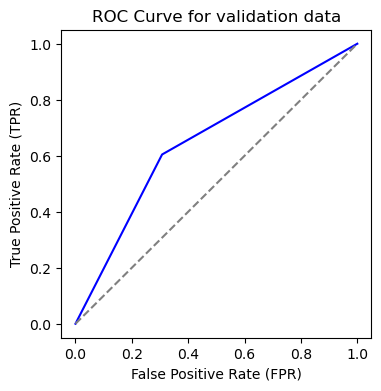

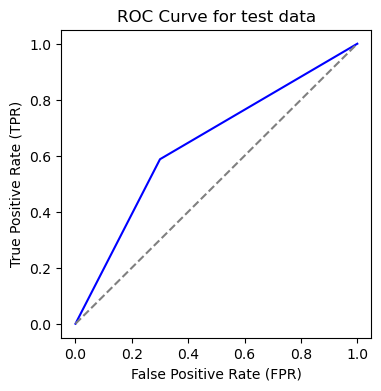

In [70]:
#from the combination best threshold is 0.35 which has auc value of 0.9259 for validation and 0.9471 for test data
threshold = 0.35
y_pred_val = (y_prob_val[:,1] >=threshold).astype(int)
y_pred_test = (y_prob_test[:,1]>=threshold).astype(int)

from sklearn.metrics import accuracy_score
accuracy_log_val = accuracy_score(y_val,y_pred_val)
accuracy_log_test = accuracy_score(y_test,y_pred_test)
print('Accuracy of validation data is %.5f and test data is %.5f'%(accuracy_log_val,accuracy_log_test))

fpr_val,tpr_val,thresholds = roc_curve(y_val,y_pred_val)
fpr_test,tpr_test,thresholdss = roc_curve(y_test,y_pred_test)
auc_val = auc(fpr_val,tpr_val)
auc_test = auc(fpr_test,tpr_test)
print('Auc value for validation data is %.5f and test data is %.5f'%(auc_val,auc_test))

# Plot ROC curve
plt.figure(figsize=(4,4))
plt.plot(fpr_val,tpr_val,color='blue')
plt.plot([0,1],[0,1],color='gray',linestyle='--') 
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for validation data')
plt.show()

plt.figure(figsize=(4,4))
plt.plot(fpr_test, tpr_test, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for test data')
plt.show()


In [71]:
from sklearn.datasets import make_classification
from sklearn.metrics import log_loss
from scipy.stats import chi2
feature_names=x_train.columns.tolist()
# 3. Extract Coefficients and Intercept
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# 4. Create a DataFrame for Coefficients and Intercept
coeff_df = pd.DataFrame({
    "Name":feature_names + ["Intercept"],
    "Value": list(coefficients) + [intercept]
})

# 5. Calculate Odds Ratios
odds_ratios = np.exp(coefficients)
odds_ratios_df = pd.DataFrame({
    "Name": feature_names,
    "Odds Ratio": odds_ratios
})

# 6. Predicted Probabilities
probs = model.predict_proba(x_train)[:, 1]

# 7. Calculate Residuals
residuals = y_train - probs

# 8. Calculate Log-Likelihood
log_likelihood = -log_loss(y_train, probs, normalize=False)

# 9. Calculate Null Model Log-Likelihood
null_model_probs = np.mean(y_train)
null_log_likelihood = -log_loss(y_train, [null_model_probs] * len(y_train), normalize=False)

# 10. Degrees of Freedom
n_params = len(coefficients) + 1  # Coefficients + intercept
n_samples = x_train.shape[0]
df_model = n_params - 1
df_residuals = n_samples - n_params

# 11. Calculate AIC and BIC
aic = 2 * n_params - 2 * log_likelihood
bic = np.log(n_samples) * n_params - 2 * log_likelihood

# 12. Calculate Pseudo R² (McFadden's R²)
pseudo_r_squared = 1 - (log_likelihood / null_log_likelihood)

# 13. Likelihood Ratio Test (LLR) and p-value
llr = 2 * (log_likelihood - null_log_likelihood)
llr_p_value = chi2.sf(llr, df_model)

# 14. Create Residuals DataFrame
residuals_df = pd.DataFrame({
    "Observed": y_train,
    "Predicted Probability": probs,
    "Residuals": residuals
})

# 15. Compile Summary of Results
summary = {
    "Log-Likelihood": log_likelihood,
    "Null Log-Likelihood": null_log_likelihood,
    "AIC": aic,
    "BIC": bic,
    "Pseudo R² (McFadden)": pseudo_r_squared,
    "Degrees of Freedom (Model)": df_model,
    "Degrees of Freedom (Residuals)": df_residuals,
    "LLR": llr,
    "LLR p-value": llr_p_value
}

# 16. Display the Coefficients DataFrame
print("=== Coefficients and Intercept ===")
print(coeff_df.to_string(index=False))

# 17. Display Odds Ratios
print("\n=== Odds Ratios ===")
print(odds_ratios_df.to_string(index=False))

# 18. Display Summary Statistics
print("\n=== Summary Statistics ===")
for key, value in summary.items():
    print(f"{key}: {value}")

# 19. Display Residuals DataFrame (First 5 Rows)
print("\n=== Residuals (First 5 Rows) ===")
print(residuals_df.head())


=== Coefficients and Intercept ===
                            Name     Value
                 compound_scores -0.000603
                          Rating  0.170893
Type_of_traveller_Couple Leisure -0.438287
Type_of_traveller_Family Leisure -0.020627
  Type_of_traveller_Solo Leisure -0.016959
         Seat_type_Economy Class -0.578059
           Seat_type_First Class -0.707498
       Seat_type_Premium Economy -0.397245
              topics_Cleanliness  0.344490
         topics_Customer Service -0.091987
                     topics_Fare  0.226608
          topics_Flight Features  0.041335
                     topics_Food  0.164464
             topics_Seat Comfort  0.273054
       topics_Special Assistance -0.193139
            topics_Staff Service  0.059558
          topics_Time Management  0.140728
                       Intercept -0.791924

=== Odds Ratios ===
                            Name  Odds Ratio
                 compound_scores    0.999397
                          Rating    1

In [72]:
model = LogisticRegression()
model.fit(x_train, y_train)  

# Extract Feature Names
feature_names = x_train.columns  # Corrected

# Extract Coefficients
coefs = model.coef_.flatten()

# Compute Odds Ratios
odds_ratios = np.exp(coefs)

# Compute Hessian Approximation using log-likelihood second derivative
X_design = np.hstack([np.ones((x_train.shape[0], 1)), x_train])  # Add intercept column
p = model.predict_proba(x_train)[:, 1]  # Compute probabilities using X_train (not X_test)
W = np.diag(p * (1 - p))  # Compute weight matrix

# Compute the covariance matrix correctly
cov_matrix = np.linalg.inv(X_design.T @ W @ X_design)  

# Extract standard errors (skip intercept term)
standard_errors = np.sqrt(np.diag(cov_matrix)[1:])  

# Compute 95% Confidence Intervals
lower_CI = np.exp(coefs - 1.96 * standard_errors)
upper_CI = np.exp(coefs + 1.96 * standard_errors)
log_odds = np.log(odds_ratios)

# Combine into a DataFrame for Display
results_df = pd.DataFrame({
    'Feature': feature_names,
    'Odds Ratio': odds_ratios,
    'Log Odds':log_odds,
    'Lower 95% CI': lower_CI,
    'Upper 95% CI': upper_CI
})

results_df

,Feature,Odds Ratio,Log Odds,Lower 95% CI,Upper 95% CI
0,compound_scores,0.999397,-0.000603,0.980751,1.018397
1,Rating,1.186364,0.170893,1.173879,1.198982
2,Type_of_traveller_Couple Leisure,0.645140,-0.438287,0.565451,0.736060
3,Type_of_traveller_Family Leisure,0.979585,-0.020627,0.884888,1.084415
4,Type_of_traveller_Solo Leisure,0.983184,-0.016959,0.885729,1.091362
5,Seat_type_Economy Class,0.560986,-0.578059,0.495579,0.635027
6,Seat_type_First Class,0.492876,-0.707498,0.279084,0.870442
7,Seat_type_Premium Economy,0.672169,-0.397245,0.511531,0.883254
8,topics_Cleanliness,1.411269,0.344490,1.029700,1.934234
9,topics_Customer Service,0.912117,-0.091987,0.772512,1.076950


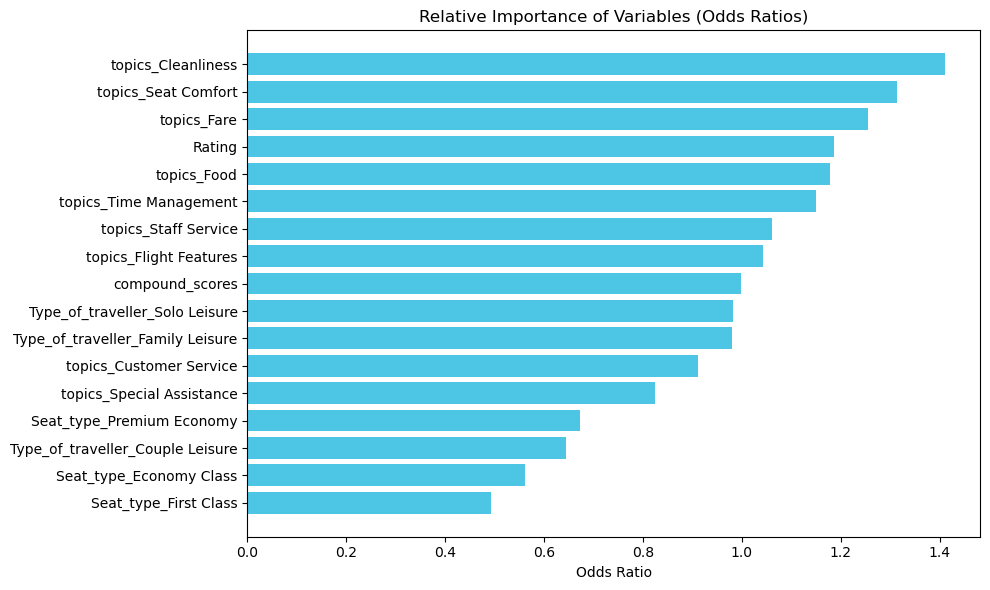

In [73]:
coefs = model.coef_.flatten()

importance = pd.DataFrame({
    "Feature": x.columns,
    "Odds Ratio": np.exp(coefs)
})

importance = importance.sort_values(by="Odds Ratio")

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Odds Ratio"], color="#4CC6E4")
plt.xlabel("Odds Ratio")
plt.title("Relative Importance of Variables (Odds Ratios)")
plt.tight_layout()
plt.show()

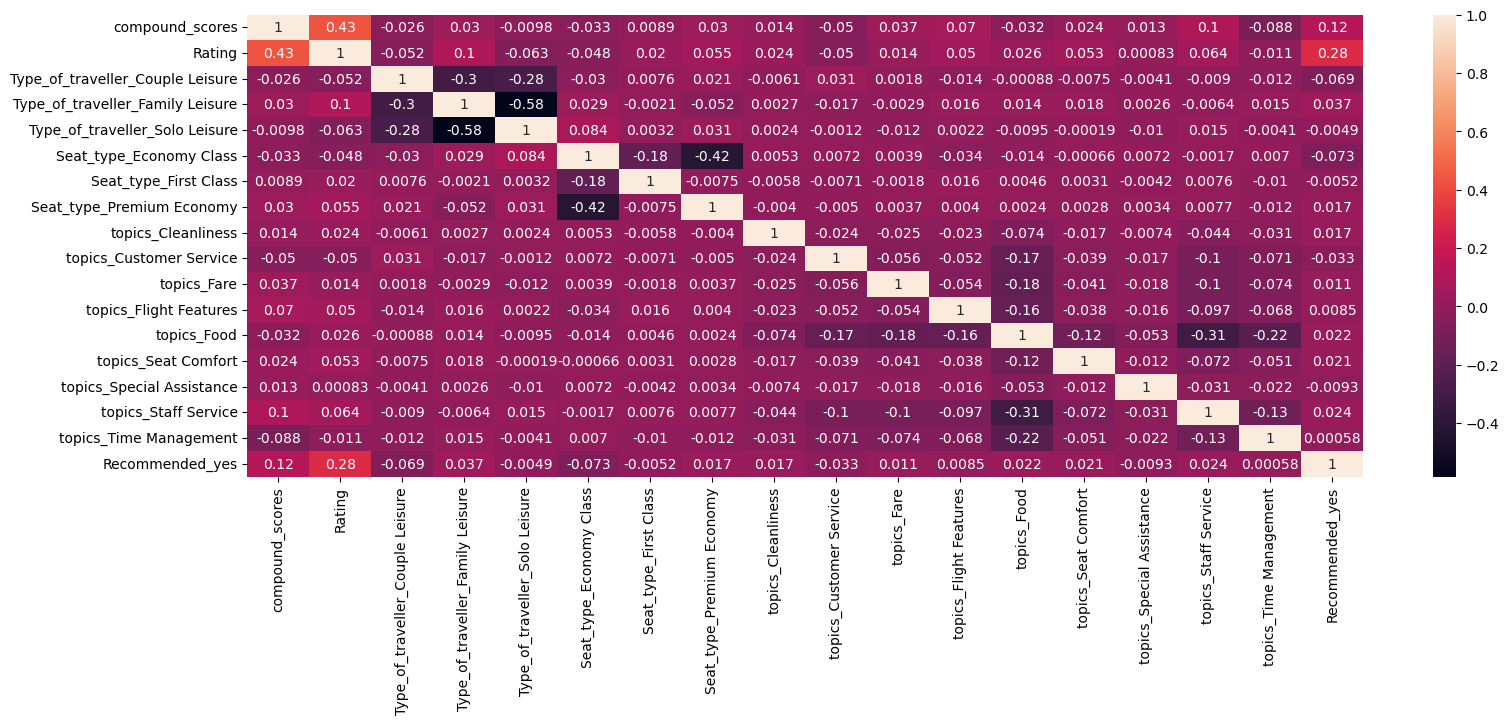

In [74]:
plt.figure(figsize=(18,6))
sns.heatmap(df_imputed.corr(),annot=True)#.xaxis.tick_top()
plt.show()

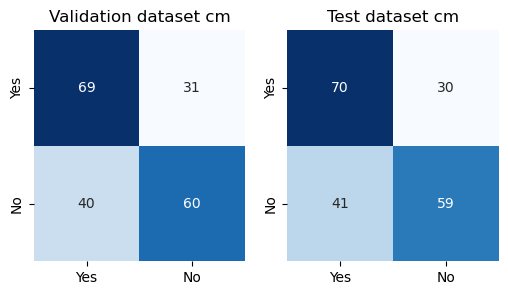

In [75]:
from sklearn.metrics import confusion_matrix
lab = ['Yes','No']
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
cm_log_val = confusion_matrix(y_val,y_pred_val)
cm_log_val = (cm_log_val/cm_log_val.sum(axis=1,keepdims=True))*100

sns.heatmap(cm_log_val,cmap='Blues',xticklabels=lab,yticklabels=lab,annot=True,cbar=0)
plt.title('Validation dataset cm')

plt.subplot(1,2,2)
cm_log_test = confusion_matrix(y_test,y_pred_test)
cm_log_test = (cm_log_test/cm_log_test.sum(axis=1,keepdims=True))*100

sns.heatmap(cm_log_test,cmap='Blues',xticklabels=lab,yticklabels=lab,annot=True,cbar=0)
plt.title('Test dataset cm')
plt.show()

In [76]:
import statsmodels.api as sm
x = sm.add_constant(x)

# Fit Logistic Regression Model
model = sm.Logit(y, x)
result = model.fit()

# Print Model Summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.606452
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        Recommended_yes   No. Observations:                25154
Model:                          Logit   Df Residuals:                    25136
Method:                           MLE   Df Model:                           17
Date:                Sun, 08 Mar 2026   Pseudo R-squ.:                 0.06899
Time:                        14:53:47   Log-Likelihood:                -15255.
converged:                       True   LL-Null:                       -16385.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.7557      0.065    -11.61